## **Retrieval Extraction with Embeddings and Cosine Similarity (Without Generation)**

Retrieval: Retrieve the most relevant passage or context using embeddings and cosine similarity.

Extraction: Extracting the most relevant answer based on embeddings and cosine similarity, without any augmentation or generation steps.

Result: The answer is extracted directly from the context provided by the retrieved passage. The answer is the most relevant passage based on similarity.There is no generative model involved.

## Embeddings

**all-MiniLM-L6-v2**: A lightweight, transformer-based model for generating efficient and high-quality sentence embeddings, good for general-purpose NLP tasks.

In [ ]:
!pip install -qqq ollama
!pip install -qqq langchain faiss-cpu python-dotenv
!pip install -qqq -U langchain-openai
!pip install -qqq langchain-core langchain-openai langchain-community
!pip install -qqq matplotlib numpy

In [ ]:
import os
print(os.getcwd())

C:\Users\henny\PYTHON\HULL\Centralized_RAG_Federated_RAG_RetrievalExtraction\Notebook


In [ ]:
import requests
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from transformers import pipeline, AutoModel, AutoTokenizer
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
import ollama
import torch
from langchain_community.embeddings import OllamaEmbeddings
import subprocess
import json
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from transformers import DistilBertForQuestionAnswering, DistilBertTokenizer
from transformers import BartTokenizer, BartForConditionalGeneration
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Ensure directory exists
os.makedirs('./data/', exist_ok=True)

In [ ]:
# Load the summary from the file
def load_summary(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        return file.read()

# Main execution
summary_file_path = './data/msc_ai_keeleonline_short.txt'
loaded_summary = load_summary(summary_file_path)

# Print the loaded summary
print(loaded_summary)

The MSc Computer Science with Artificial Intelligence Online at Keele University is delivered 100% online.
The MSc Computer Science with Artificial Intelligence Online at Keele University program takes two years to complete on a part-time basis (180 credits).
The total cost of the MSc Computer Science with Artificial Intelligence Online at Keele University is £7,440, with per-module payments (£620 per 15-credit module) and a final dissertation instalment of £1,860. Keele alumni receive a 10% discount, reducing the total to £6,696.
The start dates for the MSc Computer Science with Artificial Intelligence Online at Keele University occur six times per year.
Payment options for the MSc Computer Science with Artificial Intelligence Online at Keele University include paying per module or upfront, with UK/EU students eligible for government postgraduate loans.
The minimum academic qualification required to apply for the MSc Computer Science with Artificial Intelligence Online at Keele Univer

## Define Questions

In [ ]:
questions = [
    "Is the MSc Computer Science with Artificial Intelligence Online at Keele University delivered online?",
    "How long does the MSc Computer Science with Artificial Intelligence Online at Keele University take to complete?",
    "What is the total cost of the MSc Computer Science with Artificial Intelligence Online at Keele University?",
    "How many start dates are available each year for the MSc Computer Science with Artificial Intelligence Online at Keele University?",
    "What payment options are available for the MSc Computer Science with Artificial Intelligence Online at Keele University?",
    "What are the minimum academic entry requirements for the MSc Computer Science with Artificial Intelligence Online at Keele University?",
    "What English language proficiency requirements apply for the MSc Computer Science with Artificial Intelligence Online at Keele University?",
    "What modules are included in the MSc Computer Science with Artificial Intelligence Online at Keele University?",
    "What programming languages and tools do students use in the MSc Computer Science with Artificial Intelligence Online at Keele University?",
    "What type of learning environment and student support does the MSc Computer Science with Artificial Intelligence Online at Keele University provide?",
    "What are the qualifications of the academics teaching the MSc Computer Science with Artificial Intelligence Online at Keele University?",
    "What career opportunities are graduates of the MSc Computer Science with Artificial Intelligence Online at Keele University prepared for?",
    "What industry collaborations influence the MSc Computer Science with Artificial Intelligence Online at Keele University?"
]

ground_truth_answers = [
    "The MSc Computer Science with Artificial Intelligence Online at Keele University is delivered 100% online.",
    "The MSc Computer Science with Artificial Intelligence Online at Keele University program takes two years to complete on a part-time basis (180 credits).",
    "The total cost of the MSc Computer Science with Artificial Intelligence Online at Keele University is £7,440, with per-module payments (£620 per 15-credit module) and a final dissertation instalment of £1,860. Keele alumni receive a 10% discount, reducing the total to £6,696.",
    "The start dates for the MSc Computer Science with Artificial Intelligence Online at Keele University occur six times per year.",
    "Payment options for the MSc Computer Science with Artificial Intelligence Online at Keele University include paying per module or upfront, with UK/EU students eligible for government postgraduate loans.",
    "The minimum academic qualification required to apply for the MSc Computer Science with Artificial Intelligence Online at Keele University is a 2:2 UK undergraduate degree (or international equivalent) in a relevant field. Applicants with a third-class degree plus two or more years of relevant experience, or those with three or more years of relevant IT/data experience without a degree, may also be considered.",
    "For English language proficiency, applicants to the MSc Computer Science with Artificial Intelligence Online at Keele University must meet one of the following: IELTS 6.0 (minimum 5.5 in each skill), TOEFL 79, PTE 50, Cambridge 169 (min 162 each), Duolingo 95 (min 85 each), or hold a degree taught in English within the last five years.",
    "The MSc Computer Science with Artificial Intelligence Online at Keele University covers modules such as Applications of AI & Machine Learning, Mathematics for AI & Data Science, Statistical Data Analytics & Databases, Design & Programming, User Interaction Design, Software Engineering with Group Project, Web Technologies & Security, Research & Consultancy Skills, and MSc Project phases (Literature Review and Final Project).",
    "Students in the MSc Computer Science with Artificial Intelligence Online at Keele University will use Python, R, Matlab, XML, Anaconda, XAMPP, and WEKA as part of their studies.",
    "The MSc Computer Science with Artificial Intelligence Online at Keele University offers an interactive online environment, including multimedia lectures, peer collaboration, forum discussions, and guidance from a dedicated Student Success Coordinator.",
    "Academics teaching in the MSc Computer Science with Artificial Intelligence Online at Keele University are research-active, with 80% rated as world-leading or internationally excellent (REF 2021).",
    "Graduates of the MSc Computer Science with Artificial Intelligence Online at Keele University are prepared for careers in AI-driven sectors such as automated customer service, image/speech processing, AI analytics, and intelligent systems in logistics, factories, and online platforms.",
    "The MSc Computer Science with Artificial Intelligence Online at Keele University is informed by industry collaborations, including partnerships such as the Knowledge Transfer Partnership with Bentley Motors."
]


## A. Retrieval Extraction with 'all-'MiniLM'-v2' Embeddings and Cosine Similarity:

all-MiniLM-L6-v2' is a lightweight version of transformer model for generating sentence embeddings.

"MiniLM" in the model name refers to Microsoft's MiniLM (Miniature Language Model).

**1. Embedding Process**:
all-MiniLM-L6-v2 used to generate sentence embeddings for questions and corresponding answers.
The embeddings created using SentenceTransformer, and cosine similarity is computed between question embedding and answer embeddings.

**2.Retrieval Process**:

For each question, computes cosine similarity between question's embedding and each answer's embedding.
The answer with highest cosine similarity score is selected as the most relevant answer.

**3. Evaluation**:

*Exact Match (EM) Score* calculated by comparing each retrieved answer to  ground truth answer.

*F1 Score*: This score measures the overlap between tokens in the retrieved answer and ground truth answer, both precision (how much of  retrieved answer is relevant) and recall (how much of relevant answer was retrieved).

### A1. Embedding Process

In [ ]:
# Function to generate embeddings, find most relevant answers, save

def perform_embeddings(embedding_model_name, questions, answers):
    model = SentenceTransformer(embedding_model_name) # Load embedding model
    answer_embeddings = model.encode(answers, convert_to_tensor=True)  # Generate embeddings for answers

    predictions = []

    for question in questions:
        question_embedding = model.encode(question, convert_to_tensor=True) # Generate embedding for question
        similarities = util.pytorch_cos_sim(question_embedding, answer_embeddings)  # Compute cosine similarity between QnA
        most_similar_index = similarities.argmax() # Find index of most similar answer
        most_relevant_answer = answers[most_similar_index]  # Retrieve most relevant answer

        predictions.append(most_relevant_answer)

        print(f"Q: {question}\nA: {most_relevant_answer}\n")

    return predictions, answer_embeddings

### A2.Retrieval Process:

In [ ]:
# Define model name
embedding_model_name = "all-MiniLM-L6-v2"

# Perform QA with MiniLM embeddings
predictions, MiniLM_embeddings = perform_embeddings(embedding_model_name, questions, ground_truth_answers)

Q: Is the MSc Computer Science with Artificial Intelligence Online at Keele University delivered online?
A: The MSc Computer Science with Artificial Intelligence Online at Keele University is delivered 100% online.

Q: How long does the MSc Computer Science with Artificial Intelligence Online at Keele University take to complete?
A: The MSc Computer Science with Artificial Intelligence Online at Keele University program takes two years to complete on a part-time basis (180 credits).

Q: What is the total cost of the MSc Computer Science with Artificial Intelligence Online at Keele University?
A: The total cost of the MSc Computer Science with Artificial Intelligence Online at Keele University is £7,440, with per-module payments (£620 per 15-credit module) and a final dissertation instalment of £1,860. Keele alumni receive a 10% discount, reducing the total to £6,696.

Q: How many start dates are available each year for the MSc Computer Science with Artificial Intelligence Online at Kee

#### Save the "all-MiniLM-L6-v2" embeddings

In [ ]:
# Save embeddings
embedding_file_path = './data/MiniLM_embeddings_keele.pkl'

with open(embedding_file_path, 'wb') as f:
    pickle.dump(MiniLM_embeddings, f)

print(f"Embeddings saved to {embedding_file_path}")

Embeddings saved to ./data/MiniLM_embeddings_keele.pkl


#### Load and print the saved "all-MiniLM-L6-v2" embeddings from the file

In [ ]:
# Path to embeddings file
embedding_file_path = './data/MiniLM_embeddings_keele.pkl'

# Load embeddings from file
with open(embedding_file_path, 'rb') as f:
    loaded_embeddings = pickle.load(f)

print(f"Embeddings loaded from {embedding_file_path}:") # Print loaded embeddings
print(loaded_embeddings)

Embeddings loaded from ./data/MiniLM_embeddings_keele.pkl:
tensor([[-0.0628, -0.0406,  0.0027,  ..., -0.0039,  0.0214, -0.0098],
        [-0.0335, -0.0373,  0.0706,  ..., -0.0361, -0.0301, -0.0132],
        [-0.0274, -0.0506,  0.0491,  ..., -0.1460, -0.0125, -0.0486],
        ...,
        [-0.0076, -0.0974, -0.0113,  ..., -0.0790, -0.0258,  0.0551],
        [-0.0724, -0.0449,  0.0158,  ..., -0.0402, -0.0095, -0.0368],
        [-0.0649, -0.0251, -0.0210,  ..., -0.0948,  0.0195, -0.0132]])


### A3. Evaluation:

### Calculates the Exact Match (EM) Score and F1 Score for a retrieval-based extraction task using all-MiniLM-L6-v2 embeddings and cosine similarity.

Exact Match (EM) Score: Measures proportion of exactly matching answers between  retrievals and the ground truths.

F1 Score: Measures overlap between the retrieved and ground truth answers in terms of shared tokens, balancing precision and recall.

In [ ]:
# Function to calculate Exact Match and F1 Score
def evaluate(predictions, ground_truths):
    em_score = sum([1 if pred == truth else 0 for pred, truth in zip(predictions, ground_truths)]) / len(ground_truths)

    f1_scores = []
    for pred, truth in zip(predictions, ground_truths):
        pred_tokens = pred.split()
        truth_tokens = truth.split()
        common_tokens = set(pred_tokens) & set(truth_tokens)
        if len(common_tokens) == 0:
            f1_scores.append(0)
        else:
            precision = len(common_tokens) / len(pred_tokens)
            recall = len(common_tokens) / len(truth_tokens)
            f1 = 2 * (precision * recall) / (precision + recall)
            f1_scores.append(f1)

    f1_score_avg = sum(f1_scores) / len(f1_scores)

    return em_score, f1_score_avg

# Evaluate the predictions
em_score, f1_score_avg = evaluate(predictions, ground_truth_answers)
print(f"Exact Match (EM) Score: {em_score:.2f}")
print(f"F1 Score: {f1_score_avg:.2f}")

Exact Match (EM) Score: 0.85
F1 Score: 0.84


### A4.Visualization:

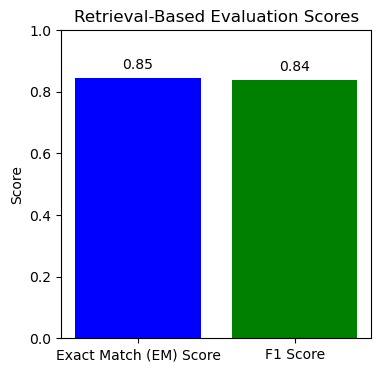

In [ ]:
# Visualize the EM and F1 scores using a bar chart
scores = [em_score, f1_score_avg]
score_labels = ['Exact Match (EM) Score', 'F1 Score']

plt.figure(figsize=(4, 4))
bars = plt.bar(score_labels, scores, color=['blue', 'green'])
plt.ylim(0, 1)  # Since scores are between 0 and 1
plt.title('Retrieval-Based Evaluation Scores')
plt.ylabel('Score')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')

plt.show()

### Interpretation:

The high Exact Match (EM) Score and F1 Score for certain questions whose answers are available in the knowledge base suggests that the retrieval-based model with cosine similarity performs adequately when relevant material is present.



In [ ]:
import os
os.makedirs('./data/', exist_ok=True)
print("Directory './data/' is ready.")

Directory './data/' is ready.


In [ ]:
'''# Save embeddings with backup option to Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Check the embedding object
print(f'Type: {type(MiniLM_embeddings)}, Length: {len(MiniLM_embeddings)}')

# Save to Google Drive
embedding_file_drive = '/content/drive/MyDrive/HULL/Thesis/CODES/gradio_apps/Retrieval_Based_Chatbot_Hull_Keele/data/MiniLM_embeddings_keele.pkl'
with open(embedding_file_drive, 'wb') as f:
    pickle.dump(MiniLM_embeddings, f)
print(f"Embeddings also backed up to {embedding_file_drive}")
'''

# Save to local
embedding_file_local = './data/MiniLM_embeddings_keele.pkl'
with open(embedding_file_local, 'wb') as f:
    pickle.dump(MiniLM_embeddings, f)
print(f"Embeddings saved locally to {embedding_file_local}")


Embeddings saved locally to ./data/MiniLM_embeddings_keele.pkl


In [ ]:
# Load embeddings from Google Drive or local
embedding_file = './data/MiniLM_embeddings_keele.pkl'
if os.path.exists(embedding_file):
    with open(embedding_file, 'rb') as f:
        loaded_embeddings = pickle.load(f)
    print(f"Embeddings loaded from {embedding_file}")
    print(f"Loaded embeddings type: {type(loaded_embeddings)}, Length: {len(loaded_embeddings)}")
else:
    print(f"Embedding file not found at {embedding_file}")

Embeddings loaded from ./data/MiniLM_embeddings_keele.pkl
Loaded embeddings type: <class 'torch.Tensor'>, Length: 13


In [ ]:
import os
os.makedirs('./data/', exist_ok=True)
print("Directory './data/' is ready.")

Directory './data/' is ready.
